# LSTM Volatility Prediction for URA (Global X Uranium ETF)

## 1. Imports and Setup

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

np.random.seed(123)
tf.random.set_seed(123)

In [56]:
TICKER = "URA"

FEATURE_COLS = ['Log_Return', 'Roll_Mean_5', 'Roll_Mean_21',
                'Roll_Std_5', 'Roll_Std_21', 'Volume_Change',
                'HL_Range', 'OC_Range']

TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15

WINDOW_SIZE = 60
TARGET_HORIZON = 21

EPOCHS = 150
LR = 0.0001
DROPOUT_RATE = 0.2
BATCH_SIZE = 64
EARLY_STOP_PATIENCE = 20
LR_DECAY_PATIENCE = 5
LR_DECAY_FACTOR = 0.5

VAR_LOSS_WEIGHT = 0.3

## 2. Data Acquisition

In [57]:
yf.set_tz_cache_location('.yf_cache')
data = yf.download(TICKER, period="max", auto_adjust=True, progress=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
missing_cols = [col for col in required_cols if col not in data.columns]
if data.empty:
    raise ValueError('No data downloaded for URA.')
if missing_cols:
    raise ValueError(f'Missing columns: {missing_cols}')

print(f"URA dataset shape: {data.shape}")
print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")

[*********************100%***********************]  1 of 1 completed

URA dataset shape: (3881, 5)
Date range: 2010-11-05 to 2026-04-14


## 3. Input Data Before Preprocessing

Raw data sample (first 5 rows):
Price            Open       High        Low      Close  Volume
Date                                                          
2010-11-05  66.855810  66.855810  64.296366  66.739471   48233
2010-11-08  67.670182  74.185135  67.166050  74.185135  255017
2010-11-09  75.077056  77.248702  70.966432  71.742020  334967
2010-11-10  72.362491  73.099300  69.803046  72.866623  121967
2010-11-11  73.680983  73.758543  71.819570  73.487083  111767

Raw data statistics:
Price     Open     High      Low    Close       Volume
count  3881.00  3881.00  3881.00  3881.00      3881.00
mean     21.65    21.92    21.31    21.62   1010616.49
std      14.38    14.56    14.09    14.33   1633452.92
min       5.71     5.94     5.58     5.70      4883.00
25%      10.34    10.45    10.23    10.34     61033.00
50%      18.57    18.79    18.22    18.55    176300.00
75%      26.46    26.76    26.02    26.43   1486800.00
max      88.15    88.66    86.84    88.11  14166800.00


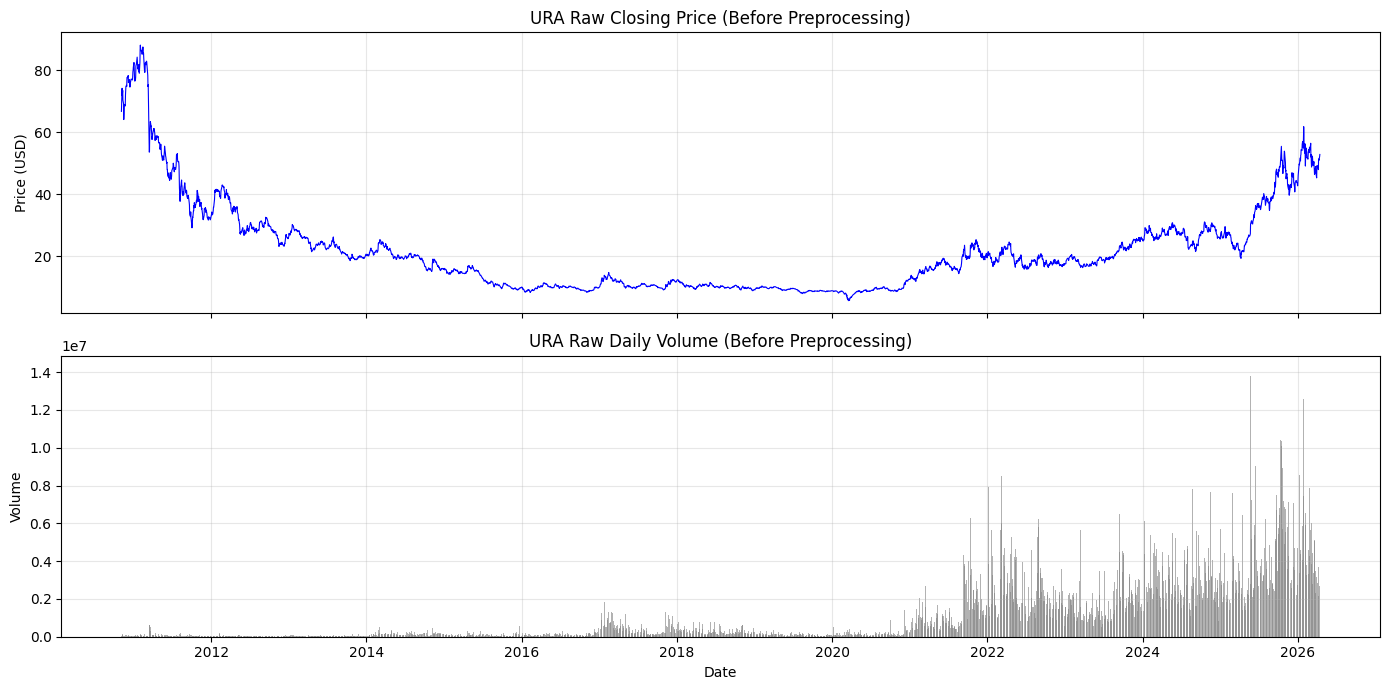

In [58]:
print("Raw data sample (first 5 rows):")
print(data[['Open', 'High', 'Low', 'Close', 'Volume']].head())
print(f"\nRaw data statistics:")
print(data[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(data.index, data['Close'], color='blue', linewidth=0.8)
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('URA Raw Closing Price (Before Preprocessing)')
axes[0].grid(True, alpha=0.3)
axes[1].bar(data.index, data['Volume'], color='grey', alpha=0.6, width=2)
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')
axes[1].set_title('URA Raw Daily Volume (Before Preprocessing)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Feature Engineering and Preprocessing

In [59]:
# Log returns
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

# Rolling features
data['Roll_Mean_5'] = data['Log_Return'].rolling(5).mean()
data['Roll_Mean_21'] = data['Log_Return'].rolling(21).mean()
data['Roll_Std_5'] = data['Log_Return'].rolling(5).std()
data['Roll_Std_21'] = data['Log_Return'].rolling(21).std()

# Volume and range features
data['Volume_Change'] = data['Volume'].pct_change()
data['HL_Range'] = (data['High'] - data['Low']) / data['Close']
data['OC_Range'] = (data['Close'] - data['Open']) / data['Open']

# Target: 21-day forward realised volatility
data['Target_Vol_21'] = data['Log_Return'].rolling(TARGET_HORIZON).std().shift(-TARGET_HORIZON)

print("Engineered features sample (first 5 valid rows):")
print(data[FEATURE_COLS].dropna().head())

Engineered features sample (first 5 valid rows):
Price       Log_Return  Roll_Mean_5  Roll_Mean_21  Roll_Std_5  Roll_Std_21  \
Date                                                                         
2010-12-07    0.001983     0.009120      0.007605    0.014062     0.036814   
2010-12-08   -0.029658    -0.003540      0.001156    0.014933     0.029987   
2010-12-09    0.010152    -0.002410      0.003234    0.015878     0.028961   
2010-12-10    0.000505    -0.002009      0.002517    0.015932     0.028827   
2010-12-13    0.002017    -0.003000      0.002210    0.015378     0.028794   

Price       Volume_Change  HL_Range  OC_Range  
Date                                           
2010-12-07       0.664573  0.032689 -0.026519  
2010-12-08      -0.271756  0.034184 -0.030663  
2010-12-09      -0.433036  0.020202  0.007634  
2010-12-10      -0.133674  0.028773 -0.002518  
2010-12-13      -0.103901  0.018136 -0.014399  


### 4.1 GARCH(1,1) Baseline

In [60]:
returns_pct = data['Log_Return'].dropna() * 100
am = arch_model(returns_pct, vol='Garch', p=1, o=0, q=1, mean='Constant', dist='normal')
garch_result = am.fit(disp='off')

data['GARCH_Vol'] = garch_result.conditional_volatility / 100.0

print("GARCH(1,1) parameters:")
print(f"  omega = {garch_result.params['omega']:.6f}")
print(f"  alpha = {garch_result.params['alpha[1]']:.6f}")
print(f"  beta  = {garch_result.params['beta[1]']:.6f}")
print(f"  persistence (alpha + beta) = {garch_result.params['alpha[1]'] + garch_result.params['beta[1]']:.6f}")

GARCH(1,1) parameters:
  omega = 0.076211
  alpha = 0.065121
  beta  = 0.922287
  persistence (alpha + beta) = 0.987407


In [61]:
data.dropna(subset=FEATURE_COLS + ['Target_Vol_21', 'GARCH_Vol'], inplace=True)

print(f"Final dataset: {len(data)} trading days ({data.index.min().date()} to {data.index.max().date()})\n")
print("Target variable (21-day forward volatility) statistics:")
print(data['Target_Vol_21'].describe())

Final dataset: 3839 trading days (2010-12-07 to 2026-03-13)

Target variable (21-day forward volatility) statistics:
count    3839.000000
mean        0.020921
std         0.008761
min         0.006234
25%         0.014874
50%         0.019320
75%         0.024543
max         0.059742
Name: Target_Vol_21, dtype: float64


## 5. Input Data After Preprocessing

In [62]:
# Chronological split
n = len(data)
train_end = int(n * TRAIN_SPLIT)
val_end = int(n * (TRAIN_SPLIT + VAL_SPLIT))

train_data = data.iloc[:train_end]
val_data = data.iloc[train_end:val_end]
test_data = data.iloc[val_end:]

print(f"Training:   {len(train_data)} rows ({train_data.index.min().date()} to {train_data.index.max().date()})")
print(f"Validation: {len(val_data)} rows ({val_data.index.min().date()} to {val_data.index.max().date()})")
print(f"Test:       {len(test_data)} rows ({test_data.index.min().date()} to {test_data.index.max().date()})")

Training:   2687 rows (2010-12-07 to 2021-08-10)
Validation: 576 rows (2021-08-11 to 2023-11-22)
Test:       576 rows (2023-11-24 to 2026-03-13)


In [63]:
feature_scaler = StandardScaler()
train_features = feature_scaler.fit_transform(train_data[FEATURE_COLS])
val_features = feature_scaler.transform(val_data[FEATURE_COLS])
test_features = feature_scaler.transform(test_data[FEATURE_COLS])

target_scaler = StandardScaler()
train_target = target_scaler.fit_transform(train_data[['Target_Vol_21']].values).flatten()
val_target = target_scaler.transform(val_data[['Target_Vol_21']].values).flatten()
test_target = target_scaler.transform(test_data[['Target_Vol_21']].values).flatten()

print(f"Target scaler: mean={target_scaler.mean_[0]:.6f}, std={target_scaler.scale_[0]:.6f}")
print(f"Scaled target range (train): [{train_target.min():.2f}, {train_target.max():.2f}]")

# Show scaled features sample
print("\nScaled features sample (first 3 rows of training set):")
print(pd.DataFrame(train_features[:3], columns=FEATURE_COLS).round(3))

Target scaler: mean=0.018589, std=0.008221
Scaled target range (train): [-1.50, 5.01]

Scaled features sample (first 3 rows of training set):
   Log_Return  Roll_Mean_5  Roll_Mean_21  Roll_Std_5  Roll_Std_21  \
0       0.126        0.960         1.662      -0.280        2.216   
1      -1.426       -0.292         0.349      -0.195        1.387   
2       0.527       -0.180         0.772      -0.103        1.262   

   Volume_Change  HL_Range  OC_Range  
0          0.443     0.807    -1.554  
1         -0.536     0.924    -1.806  
2         -0.704    -0.174     0.528  


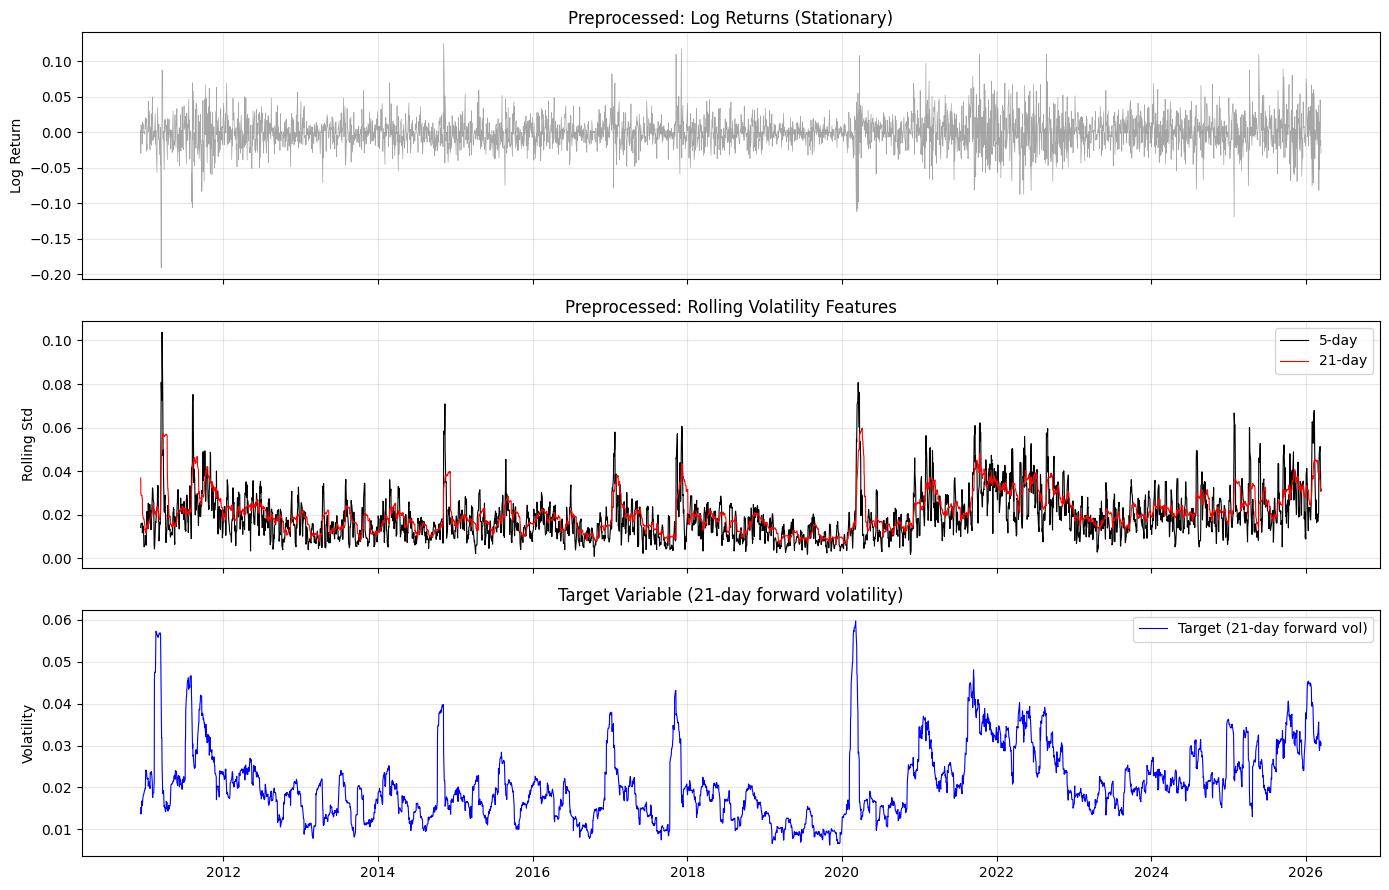

In [64]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(data.index, data['Log_Return'], color='grey', linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('Log Return')
axes[0].set_title('Preprocessed: Log Returns (Stationary)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(data.index, data['Roll_Std_5'], color='black', linewidth=0.8, label='5-day')
axes[1].plot(data.index, data['Roll_Std_21'], color='red', linewidth=0.8, label='21-day')
axes[1].set_ylabel('Rolling Std')
axes[1].set_title('Preprocessed: Rolling Volatility Features')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(data.index, data['Target_Vol_21'], color='blue', linewidth=0.8, label='Target (21-day forward vol)')
axes[2].set_ylabel('Volatility')
axes[2].set_title('Target Variable (21-day forward volatility)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
def create_sequences(features, target, window_size):
    X, y = [], []
    for i in range(window_size, len(features)):
        X.append(features[i - window_size:i])
        y.append(target[i])
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = create_sequences(train_features, train_target, WINDOW_SIZE)
X_val_seq, y_val_seq = create_sequences(val_features, val_target, WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(test_features, test_target, WINDOW_SIZE)

train_dates = train_data.index[WINDOW_SIZE:]
val_dates = val_data.index[WINDOW_SIZE:]
test_dates = test_data.index[WINDOW_SIZE:]

print(f"Training sequences:   {X_train_seq.shape}")
print(f"Validation sequences: {X_val_seq.shape}")
print(f"Test sequences:       {X_test_seq.shape}")

Training sequences:   (2627, 60, 8)
Validation sequences: (516, 60, 8)
Test sequences:       (516, 60, 8)


## 6. Model Architecture

In [66]:
def mse_variance_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    pred_var = tf.math.reduce_variance(y_pred)
    true_var = tf.math.reduce_variance(y_true)
    var_ratio = pred_var / (true_var + 1e-8)
    var_penalty = tf.square(1.0 - var_ratio)
    return mse + VAR_LOSS_WEIGHT * var_penalty


n_features = X_train_seq.shape[2]

model = Sequential([
    Input(shape=(WINDOW_SIZE, n_features)),
    LSTM(64, return_sequences=True),
    Dropout(DROPOUT_RATE),
    LSTM(32, return_sequences=False),
    Dropout(DROPOUT_RATE),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss=mse_variance_loss,
    metrics=['mae']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Training

In [67]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=LR_DECAY_FACTOR,
    patience=LR_DECAY_PATIENCE,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")
print(f"Best validation loss: {min(history.history['val_loss']):.6f}")

Epoch 1/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - loss: 1.1127 - mae: 0.6117 - val_loss: 1.2602 - val_mae: 0.7812 - learning_rate: 1.0000e-04
Epoch 2/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 1.0142 - mae: 0.5743 - val_loss: 0.9613 - val_mae: 0.7026 - learning_rate: 1.0000e-04
Epoch 3/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.9506 - mae: 0.5681 - val_loss: 0.7653 - val_mae: 0.6386 - learning_rate: 1.0000e-04
Epoch 4/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.9155 - mae: 0.5778 - val_loss: 0.7015 - val_mae: 0.6068 - learning_rate: 1.0000e-04
Epoch 5/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.8966 - mae: 0.5844 - val_loss: 0.6979 - val_mae: 0.5904 - learning_rate: 1.0000e-04
Epoch 6/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.8860 - mae: 0.5828 - val_loss: 0.7186 - val_mae: 0.5804 - learning_rate: 1.0000e-04
Epoch 7/150
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.8755 - mae: 0.5813 - val_loss: 0.7524 - val_mae: 0.5745 - lear

### 7.1 Training and Validation Loss

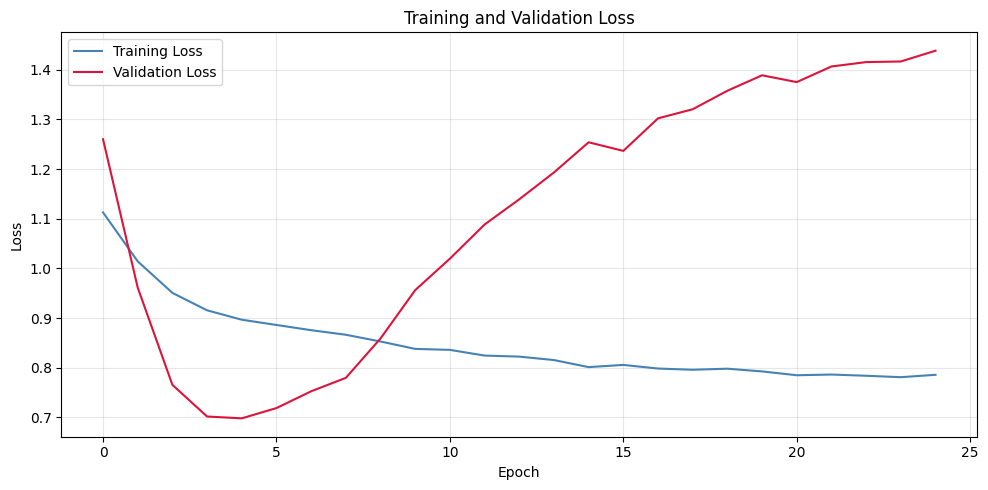

Final training loss:   0.785608
Final validation loss: 1.438516
Val/Train loss ratio:  1.83


In [68]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'], label='Training Loss', color='steelblue', linewidth=1.5)
ax.plot(history.history['val_loss'], label='Validation Loss', color='crimson', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
ratio = final_val_loss / final_train_loss
print(f"Final training loss:   {final_train_loss:.6f}")
print(f"Final validation loss: {final_val_loss:.6f}")
print(f"Val/Train loss ratio:  {ratio:.2f}")

## 8. Evaluation

### 8.1 Predictions

In [69]:
pred_test_scaled = model.predict(X_test_seq).flatten()
pred_val_scaled = model.predict(X_val_seq).flatten()
pred_train_scaled = model.predict(X_train_seq).flatten()

y_pred_test = target_scaler.inverse_transform(pred_test_scaled.reshape(-1, 1)).flatten()
y_actual_test = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

y_pred_val = target_scaler.inverse_transform(pred_val_scaled.reshape(-1, 1)).flatten()
y_actual_val = target_scaler.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()

y_pred_train = target_scaler.inverse_transform(pred_train_scaled.reshape(-1, 1)).flatten()
y_actual_train = target_scaler.inverse_transform(y_train_seq.reshape(-1, 1)).flatten()

# GARCH baseline aligned to test set
garch_test_pred = test_data['GARCH_Vol'].iloc[WINDOW_SIZE:].values
min_len = min(len(garch_test_pred), len(y_actual_test))
garch_test_pred = garch_test_pred[:min_len]

# Metrics
lstm_r2 = r2_score(y_actual_test, y_pred_test)
lstm_rmse = np.sqrt(mean_squared_error(y_actual_test, y_pred_test))
lstm_mae = mean_absolute_error(y_actual_test, y_pred_test)
garch_r2 = r2_score(y_actual_test[:min_len], garch_test_pred)
garch_rmse = np.sqrt(mean_squared_error(y_actual_test[:min_len], garch_test_pred))

print(f"LSTM  -- R2: {lstm_r2:.4f}, RMSE: {lstm_rmse:.6f}, MAE: {lstm_mae:.6f}")
print(f"GARCH -- R2: {garch_r2:.4f}, RMSE: {garch_rmse:.6f}")
if lstm_r2 > garch_r2:
    print(f"\nLSTM outperforms GARCH on R2 by {lstm_r2 - garch_r2:.4f}")
else:
    print(f"\nGARCH outperforms LSTM on R2 by {garch_r2 - lstm_r2:.4f}")

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
LSTM  -- R2: 0.0334, RMSE: 0.006487, MAE: 0.005060
GARCH -- R2: -0.1578, RMSE: 0.007100

LSTM outperforms GARCH on R2 by 0.1912


### 8.2 True Labels vs Predictions and Residuals

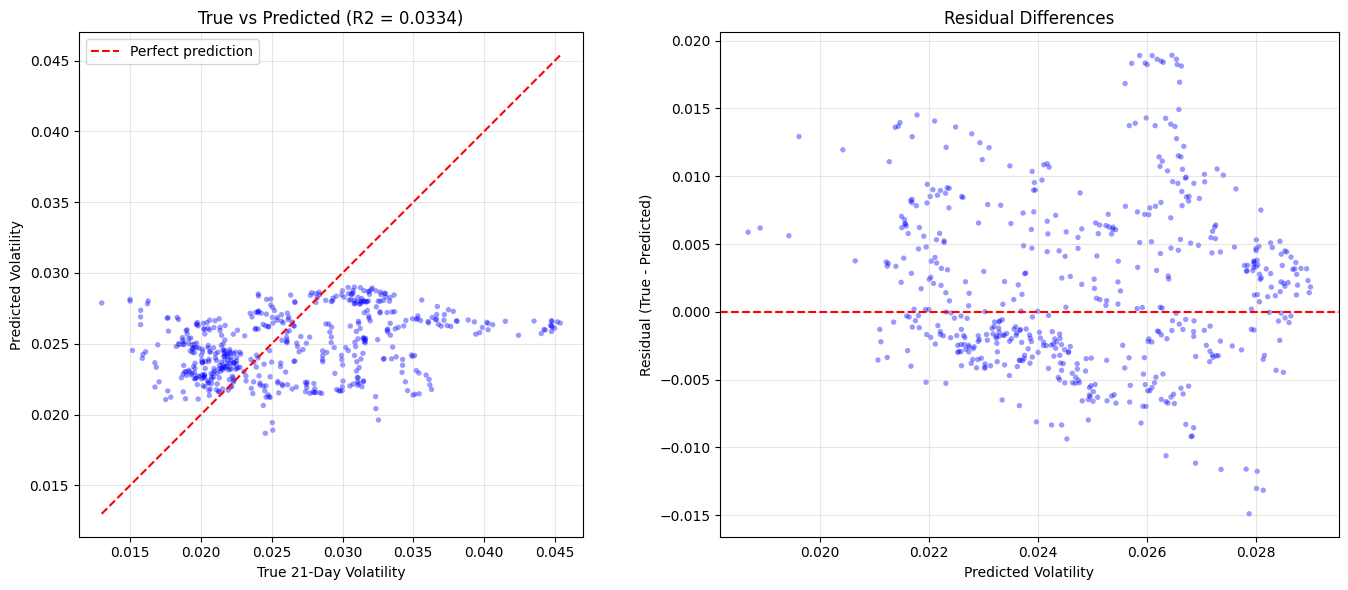

Residual mean:   0.001726
Residual std:    0.006253


In [70]:
residuals = y_actual_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# True vs Predicted scatter
axes[0].scatter(y_actual_test, y_pred_test, alpha=0.4, s=15, color='blue', edgecolors='none')
lims = [min(y_actual_test.min(), y_pred_test.min()), max(y_actual_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('True 21-Day Volatility')
axes[0].set_ylabel('Predicted Volatility')
axes[0].set_title(f'True vs Predicted (R2 = {lstm_r2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Residuals
axes[1].scatter(y_pred_test, residuals, alpha=0.4, s=15, color='blue', edgecolors='none')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Volatility')
axes[1].set_ylabel('Residual (True - Predicted)')
axes[1].set_title('Residual Differences')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual mean:   {residuals.mean():.6f}")
print(f"Residual std:    {residuals.std():.6f}")

### 8.3 Predicted vs True Volatility Over Time

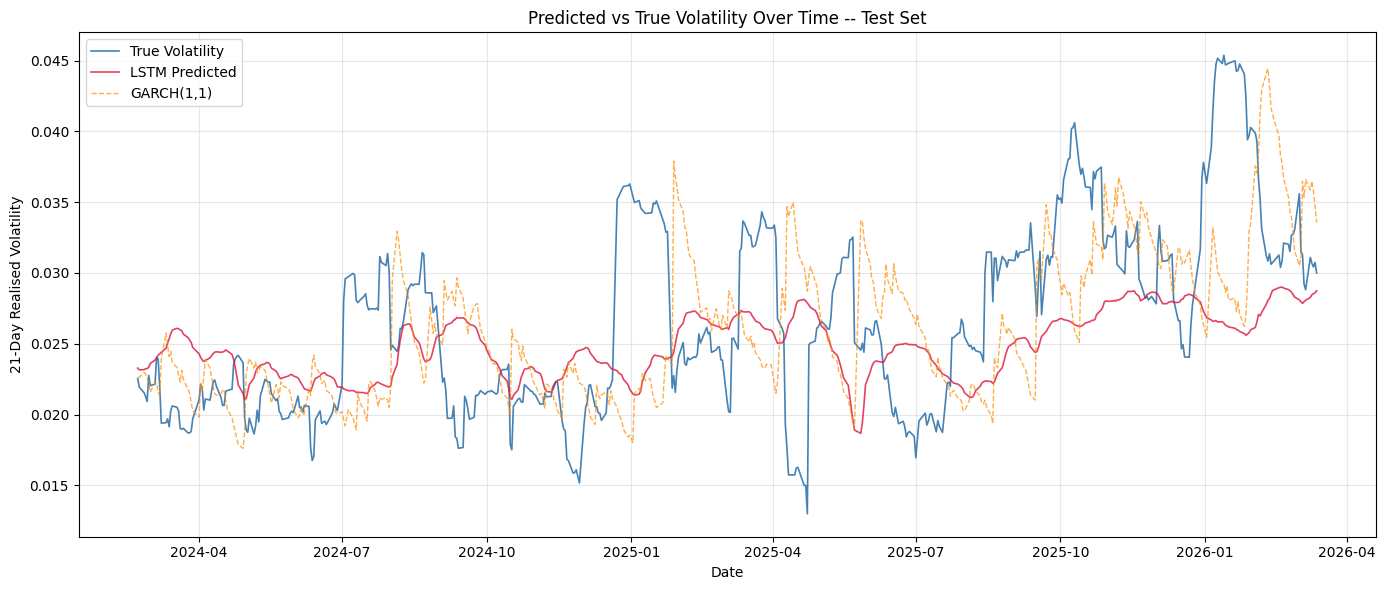

In [71]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates[:len(y_actual_test)], y_actual_test, label='True Volatility', color='steelblue', linewidth=1.2)
ax.plot(test_dates[:len(y_pred_test)], y_pred_test, label='LSTM Predicted', color='crimson', linewidth=1.2, alpha=0.8)
ax.plot(test_dates[:len(garch_test_pred)], garch_test_pred, label='GARCH(1,1)', color='darkorange', linewidth=1.0, alpha=0.7, linestyle='--')

ax.set_xlabel('Date')
ax.set_ylabel('21-Day Realised Volatility')
ax.set_title('Predicted vs True Volatility Over Time -- Test Set')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.4 Summary

In [72]:
sets = {
    'Training': (y_actual_train, y_pred_train),
    'Validation': (y_actual_val, y_pred_val),
    'Test (LSTM)': (y_actual_test, y_pred_test),
    'Test (GARCH)': (y_actual_test[:min_len], garch_test_pred)
}

results = []
for name, (true, pred) in sets.items():
    results.append({
        'Set': name,
        'RMSE': np.sqrt(mean_squared_error(true, pred)),
        'MAE': mean_absolute_error(true, pred),
        'R2': r2_score(true, pred)
    })

results_df = pd.DataFrame(results).set_index('Set')
print(results_df.to_string(float_format='{:.6f}'.format))

                 RMSE      MAE        R2
Set                                     
Training     0.007256 0.004803  0.147294
Validation   0.005767 0.004854  0.420197
Test (LSTM)  0.006487 0.005060  0.033424
Test (GARCH) 0.007100 0.005568 -0.157809
